# SC-OTS: Simplicial-Constrained Oblique Tree Sums

This notebook demonstrates the **SC-OTS** (Simplicial-Constrained Oblique Tree Sums) experiment pipeline:

1. **Interaction Distance Matrix**: Compute target-aware interaction distances between features using decision trees
2. **Vietoris-Rips Simplicial Complex**: Build simplicial complexes via GUDHI to discover multi-way feature interactions
3. **Persistent Simplices**: Extract persistent simplices as feature interaction groups
4. **SC-OTS Model**: Constrain oblique Ridge-regression splits in a FIGS-style greedy tree sum using discovered interactions
5. **Evaluation**: Compare SC-OTS against baselines (FIGS, RO-FIGS, XGBoost, XGBoost+SC, EBM) with cross-validation

We demonstrate on the **Friedman #1** synthetic dataset, which has known feature interactions (`y = 10*sin(pi*x0*x1) + 20*(x2-0.5)^2 + 10*x3 + 5*x4`).

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# Packages NOT pre-installed on Colab (always install everywhere)
_pip('gudhi==3.11.0')
_pip('imodels==2.0.4')
_pip('shap==0.46.0')
_pip('loguru==0.7.3')

# Core packages (pre-installed on Colab, install locally to match Colab env)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scikit-learn==1.6.1',
         'scipy==1.16.3', 'matplotlib==3.10.0', 'xgboost==3.1.3')


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
mlxtend 0.24.0 requires matplotlib>=3.10.8, but you have matplotlib 3.10.0 which is incompatible.
mlxtend 0.24.0 requires numpy>=2.3.5, but you have numpy 2.0.2 which is incompatible.
mlxtend 0.24.0 requires pandas>=2.3.3, but you have pandas 2.2.2 which is incompatible.
mlxtend 0.24.0 requires scikit-learn>=1.8.0, but you have scikit-learn 1.6.1 which is incompatible.

[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
from __future__ import annotations

import gc
import json
import os
import random
import sys
import time
import warnings
from dataclasses import dataclass
from itertools import combinations
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

import gudhi
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from loguru import logger
from sklearn.linear_model import Ridge
from sklearn.metrics import accuracy_score, r2_score, roc_auc_score
from sklearn.tree import DecisionTreeRegressor

warnings.filterwarnings("ignore")

# Logging setup
GREEN, CYAN, END = "\033[92m", "\033[96m", "\033[0m"
LOG_FMT = (
    f"{GREEN}{{time:HH:mm:ss}}{END}|{{level:<7}}"
    f"|{CYAN}{{function}}{END}| {{message}}"
)
logger.remove()
logger.add(sys.stdout, level="INFO", format=LOG_FMT)

1

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-outputs/ai-invention-f5f9f2-simplicial-constrained-oblique-tree-sums/main/experiment_iter2_sc_ots_simplici/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded {len(data['datasets'])} dataset(s)")
for ds in data['datasets']:
    print(f"  {ds['dataset']}: {len(ds['examples'])} examples")

Loaded 1 dataset(s)
  friedman1: 80 examples


## Configuration

All tunable parameters for the SC-OTS pipeline. Adjust these to trade off between runtime and result quality.

In [5]:
# ── Tunable parameters ──
MAX_DCOR_SAMPLES = 80       # Original: 2000 — max samples for interaction distance (limited by demo data size)
MAX_RULES = 20              # Original: 20 — max splits in SC-OTS tree sum
N_FOLDS = 5                 # Original: 5 — number of cross-validation folds
RIPS_MAX_DIM = 3            # Original: 3 — max simplex dimension for Rips complex
N_RANDOM_SUBSETS = 15       # Original: 15 — random subsets for RO-FIGS ablation
XGB_N_ESTIMATORS = 100      # Original: 100 — XGBoost n_estimators
XGB_MAX_DEPTH = 6           # Original: 6 — XGBoost max_depth
EBM_MAX_ROUNDS = 500        # Original: 500 — EBM max_rounds
EBM_INTERACTIONS = 5        # Original: 5 — EBM interaction terms
SHAP_N_ESTIMATORS = 50      # Original: 50 — SHAP background model n_estimators
SHAP_N_SAMPLES = 50         # Original: 50 — SHAP explanation samples

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

## Step 0: Data Loading

Parse the loaded JSON into structured `DatasetInfo` objects with feature arrays, targets, fold assignments, and metadata.

In [6]:
@dataclass
class DatasetInfo:
    """Container for a single dataset."""
    name: str
    X: np.ndarray
    y: np.ndarray
    folds: np.ndarray
    task_type: str
    feature_names: list
    known_interactions: dict
    n_features: int
    n_samples: int
    category: str


def load_datasets(raw_data: dict) -> List[DatasetInfo]:
    """Load all datasets from parsed JSON data."""
    logger.info("Parsing datasets from loaded data")
    datasets: List[DatasetInfo] = []

    for ds_block in raw_data["datasets"]:
        name = ds_block["dataset"]
        examples = ds_block["examples"]
        ex0 = examples[0]

        X = np.array(
            [json.loads(ex["input"]) for ex in examples],
            dtype=np.float64,
        )
        task_type = ex0["metadata_task_type"]

        if task_type == "regression":
            y = np.array(
                [float(ex["output"]) for ex in examples],
                dtype=np.float64,
            )
        else:
            y = np.array(
                [int(float(ex["output"])) for ex in examples],
                dtype=np.int64,
            )

        folds = np.array([int(ex["metadata_fold"]) for ex in examples])
        feature_names = ex0.get(
            "metadata_feature_names",
            [f"f{i}" for i in range(X.shape[1])],
        )
        ki_raw = ex0.get("metadata_known_interactions", "{}")
        known_interactions = (
            json.loads(ki_raw) if isinstance(ki_raw, str) else ki_raw
        )

        info = DatasetInfo(
            name=name,
            X=X,
            y=y,
            folds=folds,
            task_type=task_type,
            feature_names=feature_names,
            known_interactions=known_interactions,
            n_features=X.shape[1],
            n_samples=X.shape[0],
            category=ex0.get("metadata_category", ""),
        )
        datasets.append(info)
        logger.info(
            f"  {name}: {info.n_samples} samples, "
            f"{info.n_features} features, task={task_type}"
        )

    logger.info(f"Loaded {len(datasets)} datasets total")
    return datasets


datasets = load_datasets(data)
dataset = datasets[0]
print(f"\nUsing dataset: {dataset.name}")
print(f"  Samples: {dataset.n_samples}, Features: {dataset.n_features}")
print(f"  Task: {dataset.task_type}")
print(f"  Known interactions: {dataset.known_interactions}")

00:21:19|INFO   |load_datasets| Parsing datasets from loaded data


00:21:19|INFO   |load_datasets|   friedman1: 80 samples, 10 features, task=regression


00:21:19|INFO   |load_datasets| Loaded 1 datasets total



Using dataset: friedman1
  Samples: 80, Features: 10
  Task: regression
  Known interactions: {'2-way': [[0, 1]], 'additive': [2, 3, 4], 'noise_features': [5, 6, 7, 8, 9], 'formula': 'y = 10*sin(pi*x0*x1) + 20*(x2-0.5)^2 + 10*x3 + 5*x4'}


## Step 1: Interaction Distance Matrix (Target-Aware)

For each feature pair (i, j), we measure how much a decision tree improves when using both features together vs. each alone. This captures **nonlinear, target-aware** interactions:

- `R2_ij - max(R2_i, R2_j)` = interaction strength
- `Distance = 1 - interaction_strength`

For friedman1, features x0 and x1 should show strong interaction because `sin(pi*x0*x1)` requires both.

In [7]:
def compute_interaction_distance_matrix(
    X: np.ndarray,
    y: np.ndarray,
    max_samples: int = MAX_DCOR_SAMPLES,
) -> np.ndarray:
    """Compute target-aware interaction distance using decision trees.

    For each pair (i,j):
      1. Fit a tree on x_i alone -> R2_i
      2. Fit a tree on x_j alone -> R2_j
      3. Fit a tree on (x_i, x_j) together -> R2_ij
      4. Interaction strength = max(0, R2_ij - max(R2_i, R2_j))
      5. Distance = 1 - interaction_strength
    """
    n, p = X.shape
    if n > max_samples:
        idx = np.random.choice(n, max_samples, replace=False)
        X = X[idx]
        y = y[idx]

    # For very high-dimensional data, pre-filter features
    feature_subset = list(range(p))
    if p > 40:
        univariate_r2 = []
        for j in range(p):
            try:
                tree = DecisionTreeRegressor(
                    max_depth=4, random_state=RANDOM_STATE
                )
                tree.fit(X[:, j:j + 1], y)
                r2 = max(0, tree.score(X[:, j:j + 1], y))
                univariate_r2.append((r2, j))
            except Exception:
                univariate_r2.append((0.0, j))
        univariate_r2.sort(reverse=True)
        feature_subset = [j for _, j in univariate_r2[:30]]

    # Compute univariate R2 for each feature
    r2_single = {}
    for j in feature_subset:
        try:
            tree = DecisionTreeRegressor(
                max_depth=4, random_state=RANDOM_STATE
            )
            tree.fit(X[:, j:j + 1], y)
            r2_single[j] = max(0.0, tree.score(X[:, j:j + 1], y))
        except Exception:
            r2_single[j] = 0.0

    # Compute pairwise interaction strength
    D = np.ones((p, p))
    np.fill_diagonal(D, 0.0)

    for i_idx in range(len(feature_subset)):
        for j_idx in range(i_idx + 1, len(feature_subset)):
            i = feature_subset[i_idx]
            j = feature_subset[j_idx]
            try:
                tree_pair = DecisionTreeRegressor(
                    max_depth=4, random_state=RANDOM_STATE
                )
                tree_pair.fit(X[:, [i, j]], y)
                r2_pair = max(0.0, tree_pair.score(X[:, [i, j]], y))

                interaction_strength = max(
                    0.0,
                    r2_pair - max(r2_single.get(i, 0), r2_single.get(j, 0)),
                )
                D[i, j] = D[j, i] = 1.0 - interaction_strength
            except Exception:
                D[i, j] = D[j, i] = 1.0

    return D

## Step 2: Vietoris-Rips Filtration & Persistence

Build a Rips complex from the interaction distance matrix using GUDHI. The persistence diagram reveals the topological structure of feature interactions. We use a largest-gap threshold selection to prune the complex.

In [8]:
def build_simplicial_complex(
    D: np.ndarray,
    max_dim: int = RIPS_MAX_DIM,
) -> Tuple[Any, Dict[int, list], float, list, list]:
    """Build Rips complex, compute persistence, select threshold."""
    rips = gudhi.RipsComplex(
        distance_matrix=D.tolist(), max_edge_length=1.0
    )
    st = rips.create_simplex_tree(max_dimension=max_dim)
    persistence = st.persistence()

    # Largest-gap threshold selection on dimension 0
    lifetimes = sorted(
        [
            death - birth
            for dim, (birth, death) in persistence
            if dim == 0 and death != float("inf") and death > birth
        ]
    )

    if len(lifetimes) >= 2:
        gaps = [
            lifetimes[i + 1] - lifetimes[i]
            for i in range(len(lifetimes) - 1)
        ]
        gap_idx = int(np.argmax(gaps))
        threshold = (lifetimes[gap_idx] + lifetimes[gap_idx + 1]) / 2
    else:
        off_diag = D[D > 0]
        threshold = (
            float(np.median(off_diag)) if len(off_diag) > 0 else 0.5
        )

    threshold = max(0.05, min(threshold, 0.95))

    # Check if we have enough edges; if not, raise threshold
    st_test = gudhi.RipsComplex(
        distance_matrix=D.tolist(), max_edge_length=1.0
    ).create_simplex_tree(max_dimension=max_dim)
    st_test.prune_above_filtration(threshold)
    n_edges = sum(
        1
        for s, _ in st_test.get_filtration()
        if len(s) == 2
    )
    p = D.shape[0]
    min_edges = max(3, p // 3)
    if n_edges < min_edges:
        off_diag = []
        for i in range(p):
            for j in range(i + 1, p):
                if D[i, j] < 1.0:
                    off_diag.append(D[i, j])
        if off_diag:
            off_diag.sort()
            idx = min(min_edges - 1, len(off_diag) - 1)
            threshold = off_diag[idx] + 0.001
            threshold = min(threshold, 0.99)

    st.prune_above_filtration(threshold)

    simplices_by_dim: Dict[int, list] = {0: [], 1: [], 2: [], 3: []}
    for simplex, filt in st.get_filtration():
        dim = len(simplex) - 1
        if dim in simplices_by_dim:
            simplices_by_dim[dim].append(list(simplex))

    try:
        betti = list(st.persistent_betti_numbers(0, threshold))
    except Exception:
        betti = [0, 0, 0]

    return st, simplices_by_dim, threshold, betti, persistence

## Step 3: SC-OTS — Simplicial-Constrained Oblique Tree Sum

The core model: a FIGS-style greedy tree sum where oblique splits are constrained to feature groups discovered by the simplicial complex. Each split uses Ridge regression on features within a single simplex to find the best linear combination.

In [9]:
@dataclass
class SCOTSNode:
    """Node in the SC-OTS tree."""
    idxs: np.ndarray
    value: float
    impurity: float
    tree_num: int
    is_root: bool = False
    depth: int = 0
    simplex: Optional[list] = None
    weights: Optional[np.ndarray] = None
    threshold: Optional[float] = None
    impurity_reduction: Optional[float] = None
    left: Optional["SCOTSNode"] = None
    right: Optional["SCOTSNode"] = None
    left_temp: Optional["SCOTSNode"] = None
    right_temp: Optional["SCOTSNode"] = None


def construct_oblique_split(
    X: np.ndarray,
    y: np.ndarray,
    idxs: np.ndarray,
    simplex_features: list,
) -> Optional[Tuple[np.ndarray, float, float, np.ndarray, np.ndarray]]:
    """Create best oblique split using features from one simplex."""
    n_at_node = int(idxs.sum())
    if n_at_node < 10:
        return None

    X_sub = X[idxs][:, simplex_features]
    y_sub = y[idxs]

    if np.std(y_sub) < 1e-10:
        return None

    try:
        ridge = Ridge(alpha=1.0)
        ridge.fit(X_sub, y_sub)
        weights = ridge.coef_.copy()
    except Exception:
        return None

    if np.all(np.abs(weights) < 1e-10):
        return None

    linear_combo = X[:, simplex_features] @ weights
    combo_at_node = linear_combo[idxs]

    sorted_vals = np.sort(combo_at_node)
    n_vals = len(sorted_vals)
    if n_vals < 2:
        return None

    n_candidates = min(50, n_vals - 1)
    indices = np.linspace(0, n_vals - 2, n_candidates, dtype=int)
    midpoints = (sorted_vals[indices] + sorted_vals[indices + 1]) / 2.0

    best_impurity_red = -np.inf
    best_threshold = None
    parent_impurity = np.var(y_sub) * n_at_node
    min_leaf = max(5, n_at_node // 20)

    for t in midpoints:
        left_mask = combo_at_node <= t
        n_left = int(left_mask.sum())
        n_right = n_at_node - n_left
        if n_left < min_leaf or n_right < min_leaf:
            continue

        right_mask = ~left_mask
        imp_left = np.var(y_sub[left_mask]) * n_left
        imp_right = np.var(y_sub[right_mask]) * n_right
        imp_red = parent_impurity - imp_left - imp_right

        if imp_red > best_impurity_red:
            best_impurity_red = imp_red
            best_threshold = t

    if best_threshold is None or best_impurity_red <= 0:
        return None

    idxs_left = (linear_combo <= best_threshold) & idxs
    idxs_right = (linear_combo > best_threshold) & idxs

    if idxs_left.sum() < 1 or idxs_right.sum() < 1:
        return None

    return weights, best_threshold, best_impurity_red, idxs_left, idxs_right


class SCOTS:
    """Simplicial-Constrained Oblique Tree Sum (SC-OTS)."""

    def __init__(
        self,
        simplices: list,
        max_rules: int = MAX_RULES,
        max_trees: Optional[int] = None,
        min_impurity_decrease: float = 0.0,
        task_type: str = "regression",
    ):
        self.simplices = simplices
        self.max_rules = max_rules
        self.max_trees = max_trees
        self.min_impurity_decrease = min_impurity_decrease
        self.task_type = task_type
        self.trees_: List[SCOTSNode] = []
        self.complexity_: int = 0

    def fit(self, X: np.ndarray, y: np.ndarray) -> "SCOTS":
        """Fit the SC-OTS model using greedy tree sum (FIGS-style)."""
        n, p = X.shape
        y = y.astype(np.float64)
        self.trees_ = []
        self.complexity_ = 0

        y_predictions_per_tree: Dict[int, np.ndarray] = {}
        y_residuals_per_tree: Dict[int, np.ndarray] = {}

        idxs = np.ones(n, dtype=bool)
        node_init = self._best_split_over_simplices(X, y, idxs, -1)
        node_init.is_root = True
        potential_splits = [node_init]

        max_iters = self.max_rules * 3
        iter_count = 0

        while potential_splits and self.complexity_ < self.max_rules:
            iter_count += 1
            if iter_count > max_iters:
                break

            potential_splits.sort(
                key=lambda nd: (
                    nd.impurity_reduction
                    if nd.impurity_reduction is not None
                    else -np.inf
                )
            )
            split_node = potential_splits.pop()

            if (
                split_node.impurity_reduction is None
                or split_node.impurity_reduction <= self.min_impurity_decrease
            ):
                break

            self.complexity_ += 1

            if split_node.is_root:
                self.trees_.append(split_node)
                for node_ in [
                    split_node,
                    split_node.left_temp,
                    split_node.right_temp,
                ]:
                    if node_ is not None:
                        node_.tree_num = len(self.trees_) - 1

                new_root = SCOTSNode(
                    idxs=np.ones(n, dtype=bool),
                    value=float(np.mean(y)),
                    impurity=float(np.var(y) * n),
                    tree_num=-1,
                    is_root=True,
                )
                potential_splits.append(new_root)

            split_node.left = split_node.left_temp
            split_node.right = split_node.right_temp
            split_node.left_temp = None
            split_node.right_temp = None

            if split_node.left is not None:
                potential_splits.append(split_node.left)
            if split_node.right is not None:
                potential_splits.append(split_node.right)

            # Update residuals
            for tree_num_ in range(len(self.trees_)):
                y_predictions_per_tree[tree_num_] = self._predict_tree(
                    self.trees_[tree_num_], X
                )
            y_predictions_per_tree[-1] = np.zeros(n)

            for tree_num_ in list(range(len(self.trees_))) + [-1]:
                y_residuals_per_tree[tree_num_] = y.copy()
                for other in range(len(self.trees_)):
                    if other != tree_num_:
                        y_residuals_per_tree[tree_num_] -= (
                            y_predictions_per_tree[other]
                        )

            new_potentials = []
            for ps in potential_splits:
                if ps.idxs.sum() < 10:
                    continue
                y_target = y_residuals_per_tree.get(ps.tree_num, y)
                updated = self._best_split_over_simplices(
                    X, y_target, ps.idxs, ps.tree_num
                )
                updated.is_root = ps.is_root
                updated.tree_num = ps.tree_num
                updated.depth = ps.depth
                new_potentials.append(updated)
            potential_splits = new_potentials

            if (
                self.max_trees is not None
                and len(self.trees_) >= self.max_trees
            ):
                potential_splits = [
                    p for p in potential_splits if not p.is_root
                ]

        return self

    def _best_split_over_simplices(
        self,
        X: np.ndarray,
        y: np.ndarray,
        idxs: np.ndarray,
        tree_num: int,
    ) -> SCOTSNode:
        """Try oblique splits for each simplex, return best Node."""
        n_at_node = int(idxs.sum())
        if n_at_node == 0:
            return SCOTSNode(
                idxs=idxs,
                value=0.0,
                impurity=0.0,
                tree_num=tree_num,
                impurity_reduction=None,
            )

        y_at_node = y[idxs]
        best_node = SCOTSNode(
            idxs=idxs,
            value=float(np.mean(y_at_node)),
            impurity=float(np.var(y_at_node) * n_at_node),
            tree_num=tree_num,
            impurity_reduction=None,
        )

        # Oblique splits from simplices (dim >= 1)
        candidates = [s for s in self.simplices if len(s) >= 2]
        if len(candidates) > 30:
            candidates = random.sample(candidates, 30)

        for simplex in candidates:
            if any(f >= X.shape[1] for f in simplex):
                continue
            result = construct_oblique_split(X, y, idxs, simplex)
            if result is None:
                continue
            weights, threshold, imp_red, idxs_left, idxs_right = result
            if imp_red > (best_node.impurity_reduction or 0):
                y_l = y[idxs_left]
                y_r = y[idxs_right]
                best_node = SCOTSNode(
                    idxs=idxs,
                    value=float(np.mean(y_at_node)),
                    impurity=float(np.var(y_at_node) * n_at_node),
                    tree_num=tree_num,
                    simplex=list(simplex),
                    weights=weights,
                    threshold=threshold,
                    impurity_reduction=imp_red,
                )
                best_node.left_temp = SCOTSNode(
                    idxs=idxs_left,
                    value=float(np.mean(y_l)),
                    impurity=float(np.var(y_l) * idxs_left.sum()),
                    tree_num=tree_num,
                )
                best_node.right_temp = SCOTSNode(
                    idxs=idxs_right,
                    value=float(np.mean(y_r)),
                    impurity=float(np.var(y_r) * idxs_right.sum()),
                    tree_num=tree_num,
                )

        # Axis-aligned splits (0-simplices) via sklearn stump
        if n_at_node >= 10:
            try:
                stump = DecisionTreeRegressor(
                    max_depth=1, random_state=RANDOM_STATE
                )
                stump.fit(X[idxs], y_at_node)
                tree = stump.tree_
                if (
                    tree.n_node_samples[0] > 0
                    and len(tree.feature) > 1
                    and tree.feature[0] >= 0
                ):
                    feat = tree.feature[0]
                    thresh = tree.threshold[0]
                    imp = tree.impurity
                    n_ns = tree.n_node_samples
                    if n_ns[0] > 0:
                        imp_red_s = (
                            imp[0]
                            - imp[1] * n_ns[1] / n_ns[0]
                            - imp[2] * n_ns[2] / n_ns[0]
                        ) * n_ns[0]
                        if imp_red_s > (
                            best_node.impurity_reduction or 0
                        ):
                            idxs_l = (X[:, feat] <= thresh) & idxs
                            idxs_r = (X[:, feat] > thresh) & idxs
                            if idxs_l.sum() > 0 and idxs_r.sum() > 0:
                                y_l = y[idxs_l]
                                y_r = y[idxs_r]
                                best_node = SCOTSNode(
                                    idxs=idxs,
                                    value=float(np.mean(y_at_node)),
                                    impurity=float(
                                        np.var(y_at_node) * n_at_node
                                    ),
                                    tree_num=tree_num,
                                    simplex=[int(feat)],
                                    weights=np.array([1.0]),
                                    threshold=float(thresh),
                                    impurity_reduction=float(imp_red_s),
                                )
                                best_node.left_temp = SCOTSNode(
                                    idxs=idxs_l,
                                    value=float(np.mean(y_l)),
                                    impurity=float(
                                        np.var(y_l) * idxs_l.sum()
                                    ),
                                    tree_num=tree_num,
                                )
                                best_node.right_temp = SCOTSNode(
                                    idxs=idxs_r,
                                    value=float(np.mean(y_r)),
                                    impurity=float(
                                        np.var(y_r) * idxs_r.sum()
                                    ),
                                    tree_num=tree_num,
                                )
            except Exception:
                pass

        return best_node

    def predict(self, X: np.ndarray) -> np.ndarray:
        """Predict target values."""
        preds = np.zeros(X.shape[0])
        for tree in self.trees_:
            preds += self._predict_tree(tree, X)
        return preds

    def _predict_tree(
        self, node: SCOTSNode, X: np.ndarray
    ) -> np.ndarray:
        preds = np.full(X.shape[0], np.nan)
        mask = np.ones(X.shape[0], dtype=bool)
        self._predict_recursive(node, X, preds, mask)
        return np.nan_to_num(preds, nan=0.0)

    def _predict_recursive(
        self,
        node: Optional[SCOTSNode],
        X: np.ndarray,
        preds: np.ndarray,
        mask: np.ndarray,
    ) -> None:
        if node is None or mask.sum() == 0:
            return
        if node.left is None and node.right is None:
            preds[mask] = node.value
            return
        if (
            node.simplex is None
            or node.weights is None
            or node.threshold is None
        ):
            preds[mask] = node.value
            return

        combo = X[:, node.simplex] @ node.weights
        left_mask = (combo <= node.threshold) & mask
        right_mask = (combo > node.threshold) & mask
        self._predict_recursive(node.left, X, preds, left_mask)
        self._predict_recursive(node.right, X, preds, right_mask)

    def get_used_simplices(self) -> List[list]:
        """Collect all simplices used in splits."""
        used: List[list] = []
        for tree in self.trees_:
            self._collect_simplices(tree, used)
        return used

    def _collect_simplices(
        self, node: Optional[SCOTSNode], acc: list
    ) -> None:
        if node is None:
            return
        if node.simplex is not None:
            acc.append(node.simplex)
        self._collect_simplices(node.left, acc)
        self._collect_simplices(node.right, acc)

## Step 4: Baselines

Define baseline models for comparison: FIGS, RO-FIGS (random oblique), XGBoost, XGBoost with simplicial constraints, and EBM.

In [10]:
def generate_random_subsets(
    n_features: int,
    n_subsets: int,
    max_size: int = 4,
) -> list:
    """Generate random feature subsets for RO-FIGS ablation."""
    subsets = []
    for _ in range(n_subsets):
        size = random.randint(2, min(max_size, n_features))
        subset = sorted(random.sample(range(n_features), size))
        subsets.append(subset)
    for i in range(n_features):
        subsets.append([i])
    return subsets


def train_figs(
    X_train: np.ndarray,
    y_train: np.ndarray,
    task_type: str,
    max_rules: int = MAX_RULES,
):
    """Train FIGS baseline."""
    from imodels import FIGSClassifier, FIGSRegressor

    if task_type == "regression":
        model = FIGSRegressor(max_rules=max_rules)
    else:
        model = FIGSClassifier(max_rules=max_rules)
    model.fit(X_train, y_train)
    return model


def train_xgboost(
    X_train: np.ndarray,
    y_train: np.ndarray,
    task_type: str,
):
    """Train XGBoost baseline."""
    from xgboost import XGBClassifier, XGBRegressor

    if task_type == "regression":
        model = XGBRegressor(
            n_estimators=XGB_N_ESTIMATORS,
            max_depth=XGB_MAX_DEPTH,
            random_state=RANDOM_STATE,
            verbosity=0,
        )
    else:
        model = XGBClassifier(
            n_estimators=XGB_N_ESTIMATORS,
            max_depth=XGB_MAX_DEPTH,
            random_state=RANDOM_STATE,
            verbosity=0,
            eval_metric="logloss",
        )
    model.fit(X_train, y_train)
    return model


def train_xgboost_sc(
    X_train: np.ndarray,
    y_train: np.ndarray,
    task_type: str,
    valid_simplices: list,
):
    """Train XGBoost with simplicial interaction constraints."""
    from xgboost import XGBClassifier, XGBRegressor

    n_features = X_train.shape[1]
    col_names = [f"f{i}" for i in range(n_features)]
    X_df = pd.DataFrame(X_train, columns=col_names)

    constraints: List[List[str]] = []
    for s in valid_simplices:
        if len(s) >= 2:
            c = [col_names[f] for f in s if f < n_features]
            if len(c) >= 2:
                constraints.append(c)

    all_feats: set = set()
    for c in constraints:
        all_feats.update(c)
    for f_name in col_names:
        if f_name not in all_feats:
            constraints.append([f_name])

    if task_type == "regression":
        model = XGBRegressor(
            n_estimators=XGB_N_ESTIMATORS,
            max_depth=XGB_MAX_DEPTH,
            interaction_constraints=constraints,
            random_state=RANDOM_STATE,
            verbosity=0,
        )
    else:
        model = XGBClassifier(
            n_estimators=XGB_N_ESTIMATORS,
            max_depth=XGB_MAX_DEPTH,
            interaction_constraints=constraints,
            random_state=RANDOM_STATE,
            verbosity=0,
            eval_metric="logloss",
        )
    model.fit(X_df, y_train)
    return model

## Step 5: Metrics & Interaction Recovery

Compute R2 (regression) or accuracy (classification), plus interaction recovery against known ground-truth interactions.

In [11]:
def compute_metric(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    task_type: str,
) -> float:
    """R2 for regression, accuracy for classification."""
    if task_type == "regression":
        return float(r2_score(y_true, y_pred))
    else:
        y_pred_labels = np.round(y_pred).astype(int)
        y_pred_labels = np.clip(y_pred_labels, 0, 1)
        return float(accuracy_score(y_true, y_pred_labels))


def compute_interaction_recovery(
    valid_simplices: list,
    known_interactions: dict,
) -> dict:
    """Compare simplices against ground truth interactions."""
    if not known_interactions:
        return {}

    gt_sets: set = set()
    for key in ["2-way", "3-way", "4-way"]:
        if key in known_interactions:
            for interaction in known_interactions[key]:
                gt_sets.add(tuple(sorted(interaction)))

    if not gt_sets:
        return {}

    gt_pairwise: set = set()
    for gt in gt_sets:
        if len(gt) == 2:
            gt_pairwise.add(gt)
        elif len(gt) > 2:
            for pair in combinations(gt, 2):
                gt_pairwise.add(tuple(sorted(pair)))

    pred_pairwise: set = set()
    for s in valid_simplices:
        if len(s) == 2:
            pred_pairwise.add(tuple(sorted(s)))
        elif len(s) > 2:
            for pair in combinations(sorted(s), 2):
                pred_pairwise.add(pair)

    if not gt_pairwise:
        return {}

    confirmed = pred_pairwise & gt_pairwise
    precision = (
        len(confirmed) / len(pred_pairwise) if pred_pairwise else 0.0
    )
    recall = (
        len(confirmed) / len(gt_pairwise) if gt_pairwise else 0.0
    )
    f1 = (
        2 * precision * recall / (precision + recall)
        if (precision + recall) > 0
        else 0.0
    )

    return {"precision": precision, "recall": recall, "f1": f1}

## Step 6: Run Evaluation

Execute the full pipeline on the Friedman #1 dataset with cross-validation. For each fold:
1. Compute interaction distance matrix on training data
2. Build simplicial complex to discover feature interactions
3. Train SC-OTS and baseline models
4. Evaluate predictions on test data

In [12]:
start_time = time.time()
model_names = ["scots", "rofigs", "figs", "xgb", "xgb_sc"]
fold_results: List[dict] = []
all_simplices_info: List[dict] = []

unique_folds = sorted(set(dataset.folds))
folds_to_run = unique_folds[:N_FOLDS]
logger.info(f"Running {len(folds_to_run)} folds on {dataset.name}")

for fold_id in folds_to_run:
    logger.info(f"-- Fold {fold_id} --")
    train_mask = dataset.folds != fold_id
    test_mask = dataset.folds == fold_id

    X_train = dataset.X[train_mask]
    y_train = dataset.y[train_mask]
    X_test = dataset.X[test_mask]
    y_test = dataset.y[test_mask]

    task_type = dataset.task_type
    n_features = dataset.n_features
    fold_result: Dict[str, Any] = {"fold": fold_id}

    # ── A: Build simplicial complex ──
    t0 = time.time()
    D = compute_interaction_distance_matrix(X_train, y_train)
    dcor_time = time.time() - t0

    st, simplices_by_dim, threshold, betti, persistence = (
        build_simplicial_complex(D, max_dim=min(RIPS_MAX_DIM, n_features - 1))
    )

    valid_simplices: List[list] = []
    for dim in [1, 2, 3]:
        valid_simplices.extend(simplices_by_dim.get(dim, []))
    for i in range(n_features):
        valid_simplices.append([i])

    fold_result["n_simplices_dim0"] = len(simplices_by_dim.get(0, []))
    fold_result["n_simplices_dim1"] = len(simplices_by_dim.get(1, []))
    fold_result["n_simplices_dim2"] = len(simplices_by_dim.get(2, []))
    fold_result["betti"] = betti
    fold_result["threshold"] = threshold

    all_simplices_info.append({
        "fold": fold_id,
        "D": D.copy(),
        "simplices_by_dim": simplices_by_dim,
        "threshold": threshold,
        "betti": betti,
    })

    n_oblique = len([s for s in valid_simplices if len(s) >= 2])
    logger.info(
        f"  Simplices: dim1={fold_result['n_simplices_dim1']}, "
        f"dim2={fold_result['n_simplices_dim2']}, "
        f"thr={threshold:.3f}, oblique={n_oblique}"
    )

    # ── B1: SC-OTS ──
    t0 = time.time()
    scots = SCOTS(
        simplices=valid_simplices,
        max_rules=MAX_RULES,
        task_type=task_type,
    )
    scots.fit(X_train, y_train)
    scots_pred = scots.predict(X_test)
    fold_result["scots_metric"] = compute_metric(y_test, scots_pred, task_type)
    fold_result["scots_splits"] = scots.complexity_
    fold_result["scots_trees"] = len(scots.trees_)
    logger.info(f"  SC-OTS: {fold_result['scots_metric']:.4f}, splits={scots.complexity_}")

    # ── B2: RO-FIGS (ablation) ──
    rand_simplices = generate_random_subsets(
        n_features=n_features,
        n_subsets=N_RANDOM_SUBSETS,
        max_size=3,
    )
    rofigs = SCOTS(
        simplices=rand_simplices,
        max_rules=MAX_RULES,
        task_type=task_type,
    )
    rofigs.fit(X_train, y_train)
    rofigs_pred = rofigs.predict(X_test)
    fold_result["rofigs_metric"] = compute_metric(y_test, rofigs_pred, task_type)
    logger.info(f"  RO-FIGS: {fold_result['rofigs_metric']:.4f}")

    # ── B3: FIGS ──
    try:
        figs_model = train_figs(X_train, y_train, task_type)
        figs_pred = figs_model.predict(X_test)
        fold_result["figs_metric"] = compute_metric(y_test, figs_pred, task_type)
    except Exception as e:
        logger.warning(f"  FIGS failed: {e}")
        fold_result["figs_metric"] = float("nan")
    logger.info(f"  FIGS: {fold_result['figs_metric']:.4f}")

    # ── B4: XGBoost ──
    xgb_model = train_xgboost(X_train, y_train, task_type)
    xgb_pred = xgb_model.predict(X_test)
    fold_result["xgb_metric"] = compute_metric(y_test, xgb_pred, task_type)
    logger.info(f"  XGBoost: {fold_result['xgb_metric']:.4f}")

    # ── B5: XGBoost + SC ──
    try:
        xgb_sc_model = train_xgboost_sc(X_train, y_train, task_type, valid_simplices)
        xgb_sc_pred = xgb_sc_model.predict(X_test)
        fold_result["xgb_sc_metric"] = compute_metric(y_test, xgb_sc_pred, task_type)
    except Exception as e:
        logger.warning(f"  XGBoost+SC failed: {e}")
        fold_result["xgb_sc_metric"] = float("nan")
    logger.info(f"  XGBoost+SC: {fold_result.get('xgb_sc_metric', 'nan')}")

    # ── Interaction recovery ──
    if dataset.known_interactions:
        recovery = compute_interaction_recovery(valid_simplices, dataset.known_interactions)
        fold_result["interaction_recovery"] = recovery
        if recovery:
            logger.info(
                f"  Interaction recovery: P={recovery.get('precision', 0):.3f}, "
                f"R={recovery.get('recall', 0):.3f}"
            )

    fold_results.append(fold_result)
    gc.collect()

elapsed = time.time() - start_time
logger.info(f"Evaluation completed in {elapsed:.1f}s")

00:21:19|INFO   |<module>| Running 5 folds on friedman1


00:21:19|INFO   |<module>| -- Fold 0 --


00:21:19|INFO   |<module>|   Simplices: dim1=3, dim2=0, thr=0.827, oblique=3


00:21:21|INFO   |<module>|   SC-OTS: 0.3206, splits=20


00:21:30|INFO   |<module>|   RO-FIGS: 0.7598


...

00:22:44|INFO   |<module>|   FIGS: 0.2773


00:22:48|INFO   |<module>|   XGBoost: 0.6640


00:22:54|INFO   |<module>|   XGBoost+SC: 0.5671791335008141


00:22:54|INFO   |<module>|   Interaction recovery: P=0.000, R=0.000


00:22:54|INFO   |<module>| Evaluation completed in 94.7s


## Results & Visualization

Aggregate results across folds and visualize: (1) model comparison bar chart, (2) interaction distance heatmap showing discovered feature interactions, and (3) interaction recovery metrics.


Results on friedman1 (5-fold CV)
Model                R²      ± Std
--------------------------------
SC-OTS           0.5405     0.1768
RO-FIGS          0.6546     0.1214
FIGS             0.4611     0.2141
XGBoost          0.5785     0.1453
XGB+SC           0.5365     0.1350

Interaction Recovery (vs ground truth):
  Precision: 0.092
  Recall:    0.400
  F1:        0.144


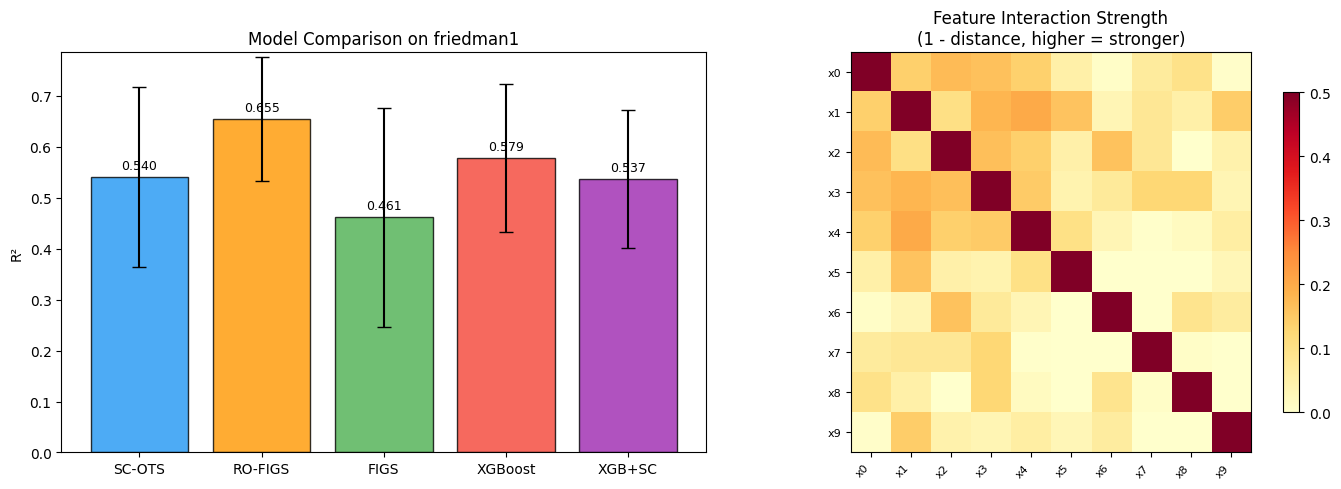


Simplicial Complex (fold 0):
  Threshold: 0.827
  Betti numbers: [6, 0, 0]
  Dim-0 simplices: 10
  Dim-1 simplices: 3
  Dim-2 simplices: 0
  Edges (feature interactions):
    x1 -- x4
    x1 -- x3
    x0 -- x2


In [13]:
# ── Aggregate results ──
model_labels = {
    "scots": "SC-OTS",
    "rofigs": "RO-FIGS",
    "figs": "FIGS",
    "xgb": "XGBoost",
    "xgb_sc": "XGB+SC",
}

mean_metrics = {}
for mn in model_names:
    vals = [
        fr[f"{mn}_metric"]
        for fr in fold_results
        if not np.isnan(fr.get(f"{mn}_metric", float("nan")))
    ]
    if vals:
        mean_metrics[mn] = {"mean": np.mean(vals), "std": np.std(vals)}

# ── Print summary table ──
metric_name = "R²" if dataset.task_type == "regression" else "Accuracy"
print(f"\n{'='*50}")
print(f"Results on {dataset.name} ({len(folds_to_run)}-fold CV)")
print(f"{'='*50}")
print(f"{'Model':<12} {metric_name:>10} {'± Std':>10}")
print(f"{'-'*32}")
for mn in model_names:
    if mn in mean_metrics:
        m = mean_metrics[mn]
        label = model_labels.get(mn, mn)
        print(f"{label:<12} {m['mean']:>10.4f} {m['std']:>10.4f}")

# ── Interaction recovery ──
recoveries = [
    fr["interaction_recovery"]
    for fr in fold_results
    if "interaction_recovery" in fr and fr["interaction_recovery"]
]
if recoveries:
    avg_prec = np.mean([r["precision"] for r in recoveries])
    avg_rec = np.mean([r["recall"] for r in recoveries])
    avg_f1 = np.mean([r["f1"] for r in recoveries])
    print(f"\nInteraction Recovery (vs ground truth):")
    print(f"  Precision: {avg_prec:.3f}")
    print(f"  Recall:    {avg_rec:.3f}")
    print(f"  F1:        {avg_f1:.3f}")

# ── Plot 1: Model comparison bar chart ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
names = [model_labels.get(mn, mn) for mn in model_names if mn in mean_metrics]
means = [mean_metrics[mn]["mean"] for mn in model_names if mn in mean_metrics]
stds = [mean_metrics[mn]["std"] for mn in model_names if mn in mean_metrics]
colors = ['#2196F3', '#FF9800', '#4CAF50', '#F44336', '#9C27B0'][:len(names)]

bars = ax.bar(names, means, yerr=stds, capsize=5, color=colors, alpha=0.8, edgecolor='black')
ax.set_ylabel(metric_name)
ax.set_title(f"Model Comparison on {dataset.name}")
ax.set_ylim(0, max(means) * 1.2 if means else 1.0)
for bar, val in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{val:.3f}", ha='center', va='bottom', fontsize=9)

# ── Plot 2: Interaction distance heatmap ──
ax = axes[1]
if all_simplices_info:
    D_show = all_simplices_info[0]["D"]
    feature_labels = dataset.feature_names[:D_show.shape[0]]
    im = ax.imshow(1.0 - D_show, cmap='YlOrRd', vmin=0, vmax=0.5)
    ax.set_xticks(range(len(feature_labels)))
    ax.set_yticks(range(len(feature_labels)))
    ax.set_xticklabels(feature_labels, rotation=45, ha='right', fontsize=8)
    ax.set_yticklabels(feature_labels, fontsize=8)
    ax.set_title("Feature Interaction Strength\n(1 - distance, higher = stronger)")
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.tight_layout()
plt.show()

# ── Simplicial complex summary ──
if all_simplices_info:
    info = all_simplices_info[0]
    print(f"\nSimplicial Complex (fold 0):")
    print(f"  Threshold: {info['threshold']:.3f}")
    print(f"  Betti numbers: {info['betti']}")
    for dim in range(3):
        n_s = len(info['simplices_by_dim'].get(dim, []))
        print(f"  Dim-{dim} simplices: {n_s}")
    edges = info['simplices_by_dim'].get(1, [])
    if edges:
        print(f"  Edges (feature interactions):")
        for e in edges[:10]:
            fname_i = dataset.feature_names[e[0]] if e[0] < len(dataset.feature_names) else f"f{e[0]}"
            fname_j = dataset.feature_names[e[1]] if e[1] < len(dataset.feature_names) else f"f{e[1]}"
            print(f"    {fname_i} -- {fname_j}")